Columns in DataFrame: ['original_text', 'labeled_text', 'masked_text']
Aggregate Masking Metrics:
{'correct': 8728, 'misplaced': 42, 'missing': 34, 'false_positive': 31}
Precision: 0.992, Recall: 0.991, F1: 0.992, Accuracy: 0.983

Per-label Counts and Metrics:
USERNAME: {'gold': 99, 'predicted': 97, 'correct': 97, 'misplaced': 2, 'missing': 0, 'false_positive': 0} - Precision: 0.980, Recall: 0.980, F1: 0.980
NAME: {'gold': 5492, 'predicted': 5494, 'correct': 5486, 'misplaced': 1, 'missing': 5, 'false_positive': 5} - Precision: 0.999, Recall: 0.999, F1: 0.999
IBAN: {'gold': 3, 'predicted': 1, 'correct': 1, 'misplaced': 1, 'missing': 1, 'false_positive': 0} - Precision: 0.500, Recall: 0.333, F1: 0.400
EMAIL: {'gold': 1205, 'predicted': 1206, 'correct': 1205, 'misplaced': 0, 'missing': 0, 'false_positive': 0} - Precision: 1.000, Recall: 1.000, F1: 1.000
LOCATION: {'gold': 1226, 'predicted': 1194, 'correct': 1193, 'misplaced': 10, 'missing': 23, 'false_positive': 14} - Precision: 0.980, Re

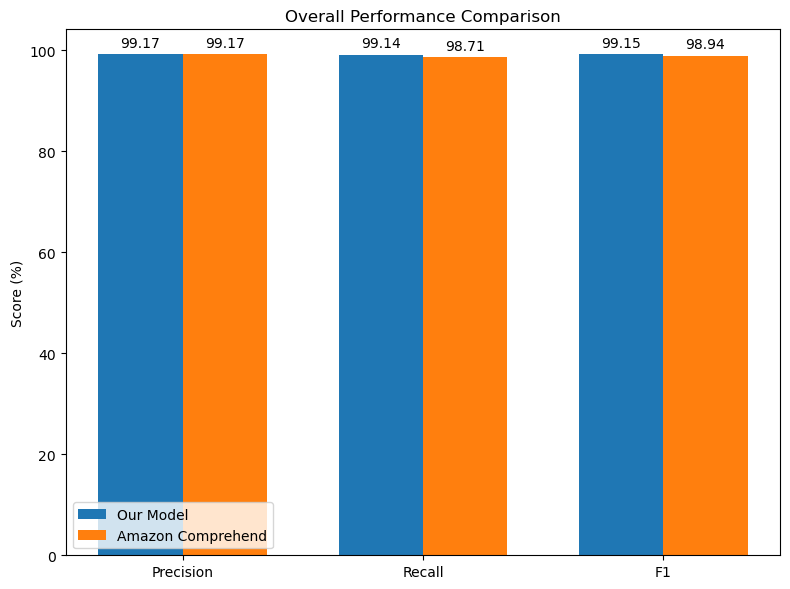

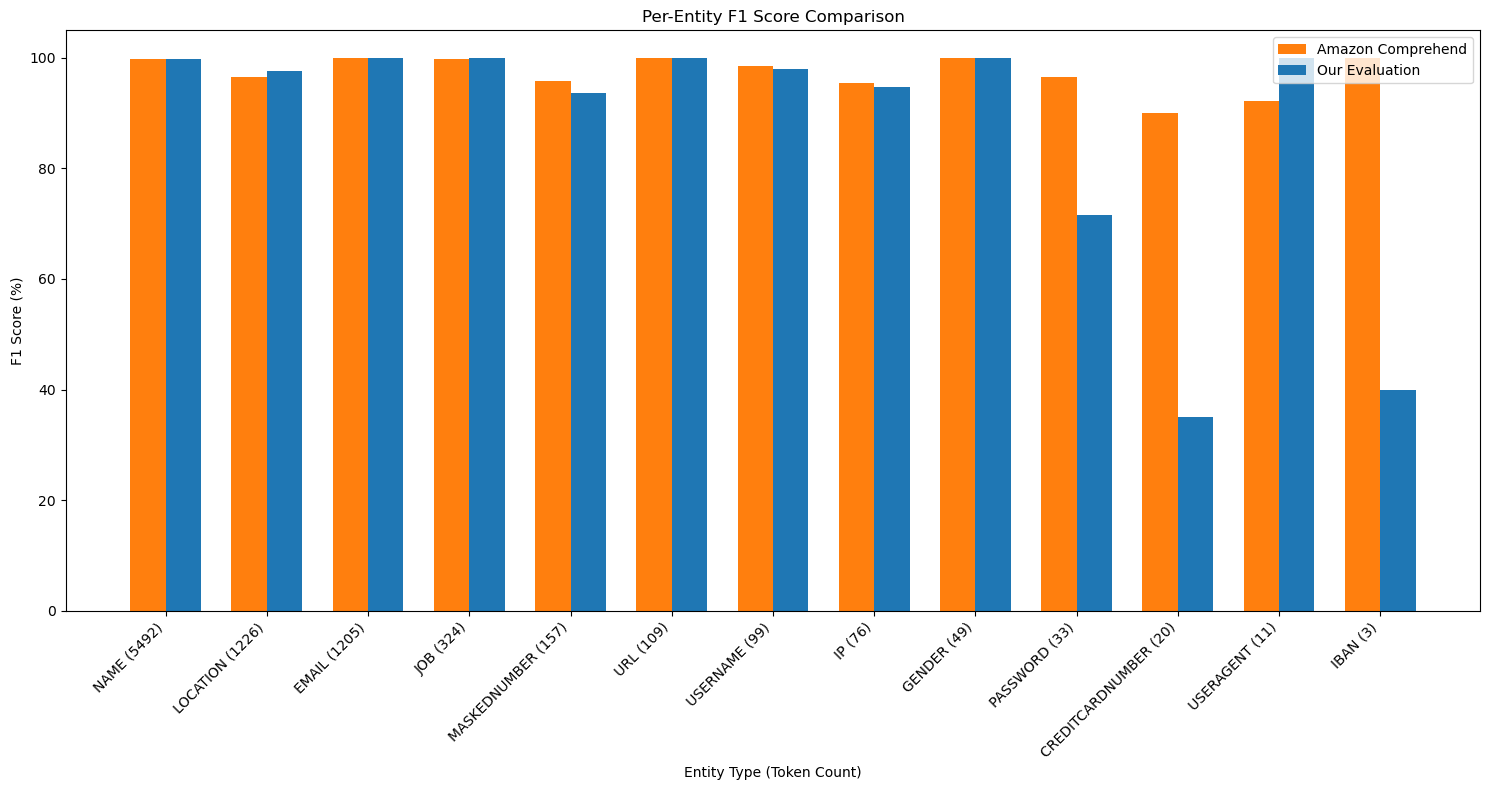

In [4]:
import re
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Global Definitions
# ---------------------------
PLACEHOLDERS = {
    "NAME", "LOCATION", "EMAIL", "JOB", "MASKEDNUMBER",
    "URL", "USERNAME", "IP", "PASSWORD", "GENDER",
    "CREDITCARDNUMBER", "USERAGENT", "IBAN"
}

# ---------------------------
# Utility Functions
# ---------------------------
def extract_masked_tokens(text, return_positions=False):
    """
    Extracts masked tokens matching known placeholders from the given text.
    If return_positions is True, returns a list of tuples (token, start, end).
    Otherwise, returns just the list of token strings.
    """
    pattern = re.compile(r'\b(' + '|'.join(PLACEHOLDERS) + r')\b', re.IGNORECASE)
    if return_positions:
        return [(m.group(), m.start(), m.end()) for m in pattern.finditer(text)]
    return pattern.findall(text)

def map_gold_span_to_pred(gold, pred, g_start, g_end):
    """
    Maps a span (g_start, g_end) from the gold text to the corresponding span in the predicted text.
    Uses SequenceMatcher to align the two strings. Returns (pred_start, pred_end) or (None, None) if mapping fails.
    """
    sm = SequenceMatcher(None, gold, pred)
    pred_start, pred_end = None, None
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if g_start >= i1 and g_start < i2:
            pred_start = j1 + (g_start - i1) if tag in ("equal", "replace") else j1
        if g_end > i1 and g_end <= i2:
            pred_end = j1 + (g_end - i1) if tag in ("equal", "replace") else j1
        if pred_start is not None and pred_end is not None:
            break
    return pred_start, pred_end

def find_overlapping_token(pred_text, mapped_span, valid_labels):
    """
    Given a predicted text and a mapped span, searches for a valid token (placeholder)
    within the span. Returns (token, (start, end)) if found, else (None, None).
    """
    p_tokens = extract_masked_tokens(pred_text, return_positions=True)
    p_start, p_end = mapped_span
    for token, start, end in p_tokens:
        if not (end < p_start or start > p_end) and token.lower() in valid_labels:
            return token, (start, end)
    return None, None

# ---------------------------
# Analysis Functions
# ---------------------------
def analyze_row_aligned(original, gold, pred):
    """
    Analyzes a single row by aligning the gold and predicted texts.
    For each gold token, maps its position to the prediction and determines if it is correct,
    misplaced, or missing. Also detects extra predicted tokens.
    
    Returns:
      - metrics: overall counts for 'correct', 'misplaced', 'missing', 'false_positive'
      - examples: dictionary with example error cases (misplaced tokens)
      - label_metrics: per-label counts of gold, predicted, correct, misplaced, missing, false_positive
    """
    gold_tokens = extract_masked_tokens(gold, return_positions=True)
    metrics = {"correct": 0, "misplaced": 0, "missing": 0, "false_positive": 0}
    examples = {"misplaced": []}
    label_metrics = { label: {"gold": 0, "predicted": 0, "correct": 0,
                               "misplaced": 0, "missing": 0, "false_positive": 0}
                      for label in PLACEHOLDERS }
    valid_labels = {p.lower() for p in PLACEHOLDERS}

    for g_token, g_start, g_end in gold_tokens:
        token_upper = g_token.upper()
        label_metrics[token_upper]["gold"] += 1

        p_start, p_end = map_gold_span_to_pred(gold, pred, g_start, g_end)
        if p_start is None or p_end is None or p_start < 0 or p_end > len(pred):
            metrics["missing"] += 1
            label_metrics[token_upper]["missing"] += 1
            examples["misplaced"].append({
                "gold": g_token,
                "predicted": None,
                "gold_span": (g_start, g_end),
                "pred_span": None,
                "note": "Mapping not found"
            })
            continue

        raw_pred = pred[p_start:p_end].strip()
        # If raw prediction is not a valid label, try to recover a valid candidate.
        if raw_pred.lower() not in valid_labels:
            candidate, candidate_span = find_overlapping_token(pred, (p_start, p_end), valid_labels)
            if candidate is not None:
                pred_token = candidate
                pred_span = candidate_span
            else:
                pred_token = raw_pred
                pred_span = (p_start, p_end)
        else:
            pred_token = raw_pred
            pred_span = (p_start, p_end)

        if pred_token.lower() not in valid_labels:
            metrics["missing"] += 1
            label_metrics[token_upper]["missing"] += 1
            examples["misplaced"].append({
                "gold": g_token,
                "predicted": pred_token,
                "gold_span": (g_start, g_end),
                "pred_span": pred_span,
                "note": "No valid label found near mapped span"
            })
        else:
            pred_label = pred_token.upper()
            label_metrics[pred_label]["predicted"] += 1
            if pred_label == token_upper:
                metrics["correct"] += 1
                label_metrics[token_upper]["correct"] += 1
            else:
                metrics["misplaced"] += 1
                label_metrics[token_upper]["misplaced"] += 1
                examples["misplaced"].append({
                    "gold": g_token,
                    "predicted": pred_token,
                    "gold_span": (g_start, g_end),
                    "pred_span": pred_span,
                    "note": "Wrong label"
                })

    # Detect extra predicted tokens that were not mapped from any gold token.
    pred_tokens = extract_masked_tokens(pred, return_positions=True)
    mapped_spans = []
    for g_token, g_start, g_end in gold_tokens:
        p_span = map_gold_span_to_pred(gold, pred, g_start, g_end)
        if p_span[0] is not None and p_span[1] is not None:
            mapped_spans.append(p_span)
    for p_token, p_start, p_end in pred_tokens:
        if not any(not (p_end < m[0] or p_start > m[1]) for m in mapped_spans):
            if p_token.lower() in valid_labels:
                metrics["false_positive"] += 1
                extra_label = p_token.upper()
                label_metrics[extra_label]["false_positive"] += 1
                examples["misplaced"].append({
                    "gold": None,
                    "predicted": p_token,
                    "gold_span": None,
                    "pred_span": (p_start, p_end),
                    "note": "Extra predicted token"
                })
    return metrics, examples, label_metrics

def analyze_masking(file_path, original_col='original_text', gold_col='labeled_text', pred_col='masked_text'):
    """
    Reads a CSV (or pickle) file containing evaluation results with columns for:
      - original_text, labeled_text (gold), and masked_text (predicted).
    Applies the row-level analysis and aggregates the metrics.
    
    Prints overall and per-label evaluation metrics.
    
    Returns:
      - all_metrics: aggregate counts (correct, misplaced, missing, false_positive)
      - metrics_df: DataFrame with per-row metrics
      - all_examples: dictionary with example error cases
      - overall_label_metrics: per-label counts
    """
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_pickle(file_path)
    
    print("Columns in DataFrame:", df.columns.tolist())
    for col in [original_col, gold_col, pred_col]:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    all_metrics = {"correct": 0, "misplaced": 0, "missing": 0, "false_positive": 0}
    all_examples = {"misplaced": []}
    detailed_results = []
    overall_label_metrics = { label: {"gold": 0, "predicted": 0, "correct": 0,
                                      "misplaced": 0, "missing": 0, "false_positive": 0}
                              for label in PLACEHOLDERS }

    for idx, row in df.iterrows():
        metrics, examples, row_label_metrics = analyze_row_aligned(
            row[original_col], row[gold_col], row[pred_col]
        )
        detailed_results.append(metrics)
        for key in all_metrics:
            all_metrics[key] += metrics.get(key, 0)
        for ex in examples["misplaced"]:
            ex["row"] = idx
            ex["original"] = row[original_col]
            ex["labeled_text"] = row[gold_col]
            ex["masked_text"] = row[pred_col]
            all_examples["misplaced"].append(ex)
        for label in overall_label_metrics:
            for key in overall_label_metrics[label]:
                overall_label_metrics[label][key] += row_label_metrics[label][key]

    metrics_df = pd.DataFrame(detailed_results)
    
    TP = all_metrics["correct"]
    FN = all_metrics["missing"] + all_metrics["misplaced"]
    FP = all_metrics["false_positive"] + all_metrics["misplaced"]
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    F1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    
    print("Aggregate Masking Metrics:")
    print(all_metrics)
    print(f"Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {F1:.3f}, Accuracy: {accuracy:.3f}\n")
    
    print("Per-label Counts and Metrics:")
    for label, counts in overall_label_metrics.items():
        TP_label = counts["correct"]
        FN_label = counts["missing"] + counts["misplaced"]
        FP_label = counts["false_positive"] + counts["misplaced"]
        precision_label = TP_label / (TP_label + FP_label) if (TP_label + FP_label) > 0 else 0
        recall_label = TP_label / (TP_label + FN_label) if (TP_label + FN_label) > 0 else 0
        f1_label = 2 * precision_label * recall_label / (precision_label + recall_label) if (precision_label + recall_label) > 0 else 0
        print(f"{label}: {counts} - Precision: {precision_label:.3f}, Recall: {recall_label:.3f}, F1: {f1_label:.3f}")
    
    return all_metrics, metrics_df, all_examples, overall_label_metrics

def compute_token_counts(file_path, gold_col="labeled_text"):
    """
    Computes token counts for each placeholder in the gold (labeled) texts.
    Returns a dictionary mapping each placeholder to its count.
    """
    df = pd.read_csv(file_path)
    counts = {label: 0 for label in PLACEHOLDERS}
    pattern = re.compile(r'\b(' + '|'.join(PLACEHOLDERS) + r')\b', re.IGNORECASE)
    for text in df[gold_col]:
        for m in pattern.finditer(text):
            token = m.group().upper()
            counts[token] += 1
    return counts

# ---------------------------
# Plotting Functions
# ---------------------------
def plot_overall_performance(metrics, our_scores, other_scores, other_label="Amazon Comprehend", output_file=None):
    """
    Plots overall performance comparison between our system and another.
    `metrics` is a list of metric names (e.g., ["Precision", "Recall", "F1"]).
    `our_scores` and `other_scores` are lists of scores in percentages.
    """
    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 6))
    bars_our = ax.bar(x - width/2, our_scores, width, label="Our Model", color='tab:blue')
    bars_other = ax.bar(x + width/2, other_scores, width, label=other_label, color='tab:orange')
    
    ax.set_ylabel("Score (%)")
    ax.set_title("Overall Performance Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    
    # Annotate bar heights
    for bar in list(bars_our) + list(bars_other):
        ax.annotate(f'{bar.get_height():.2f}', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
    
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()

def plot_entity_f1(overall_label_metrics, token_counts, output_file=None):
    """
    Plots a per-entity F1 score comparison between our evaluation and Amazon Comprehend.
    Amazon Comprehend F1 scores are hardcoded.
    """
    amazon_f1 = {
        "CREDITCARDNUMBER": 90.00, "EMAIL": 99.94, "GENDER": 100.00,
        "IBAN": 100.00, "IP": 95.41, "JOB": 99.85, "LOCATION": 96.60,
        "MASKEDNUMBER": 95.77, "NAME": 99.86, "PASSWORD": 96.55,
        "URL": 100.00, "USERAGENT": 92.30, "USERNAME": 98.55
    }
    
    our_f1 = {}
    for label, counts in overall_label_metrics.items():
        TP = counts["correct"]
        FN = counts["missing"] + counts["misplaced"]
        FP = counts["false_positive"] + counts["misplaced"]
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        our_f1[label] = f1 * 100  # Convert to percentage

    entities = list(overall_label_metrics.keys())
    # Sort entities by token count (descending)
    sorted_entities = sorted(entities, key=lambda e: token_counts.get(e, 0), reverse=True)
    amazon_scores = [amazon_f1.get(e, 0) for e in sorted_entities]
    our_scores = [our_f1.get(e, 0) for e in sorted_entities]
    labels = [f"{e} ({token_counts.get(e, 0)})" for e in sorted_entities]
    
    x = np.arange(len(sorted_entities))
    width = 0.35
    fig, ax = plt.subplots(figsize=(15, 8))
    
    ax.bar(x - width/2, amazon_scores, width, label="Amazon Comprehend", color='tab:orange')
    ax.bar(x + width/2, our_scores, width, label="Our Evaluation", color='tab:blue')
    
    ax.set_xlabel("Entity Type (Token Count)")
    ax.set_ylabel("F1 Score (%)")
    ax.set_title("Per-Entity F1 Score Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()

# ---------------------------
# Main Execution
# ---------------------------
if __name__ == "__main__":
    data_file = "dataset_1.csv"  # Adjust the file path as needed

    # Run masking analysis
    aggregate_metrics, per_row_metrics, examples, overall_label_metrics = analyze_masking(data_file)
    
    # Compute overall scores for plotting overall performance
    TP = aggregate_metrics["correct"]
    FN = aggregate_metrics["missing"] + aggregate_metrics["misplaced"]
    FP = aggregate_metrics["false_positive"] + aggregate_metrics["misplaced"]
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    our_overall_scores = [precision * 100, recall * 100, f1_score * 100]
    amazon_overall_scores = [99.17, 98.71, 98.94]  # Hardcoded Amazon Comprehend scores

    plot_overall_performance(["Precision", "Recall", "F1"], our_overall_scores, amazon_overall_scores, output_file="overall_performance.png")

    # Compute token counts and plot per-entity F1 comparison
    token_counts = compute_token_counts(data_file, gold_col="labeled_text")
    plot_entity_f1(overall_label_metrics, token_counts, output_file="entity_f1_comparison.png")
